# Projeto 2 — Sistemas Inteligentes

---



Este notebook implementa a solução pedida no enunciado do projeto, utilizando **Regressão Logística** para prever a presença de doença cardíaca com base no conjunto **Heart Disease Cleveland**.

## Objetivos atendidos
1. Pré-processamento:
   - tratamento de valores nulos com **mediana**;
   - binarização da variável **target**;
   - divisão treino/teste em **80/20** com `stratify=y`;
   - escalonamento das variáveis numéricas contínuas com `StandardScaler`.
2. Treinamento do modelo `LogisticRegression` com:
   - `solver='liblinear'`
   - `random_state=42`
   - `max_iter=1000`
3. Avaliação com:
   - acurácia
   - precisão
   - recall
   - F1-score
   - curva ROC e AUC

## 1. Importação das bibliotecas

Nesta etapa importamos as bibliotecas necessárias para:
- manipulação dos dados;
- divisão treino/teste;
- pré-processamento;
- treinamento do modelo;
- avaliação das métricas;
- visualização da curva ROC.


In [19]:
# Bibliotecas para manipulação de dados
import numpy as np
import pandas as pd

# Bibliotecas para visualização
import matplotlib.pyplot as plt

# Ferramentas do scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# Opcional: deixa o DataFrame mais legível no notebook
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


## 2. Carregamento do dataset



*   O dataset foi baixado manualmente e importado para um armazenamento local



In [20]:
# Carregamento do dataset a partir do arquivo ZIP local
import zipfile

zip_path = "/content/heart+disease.zip"

# Nomes das colunas conforme a documentação do Cleveland dataset
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

with zipfile.ZipFile(zip_path, "r") as z:
    files_in_zip = z.namelist();

    cleveland_file = None
    for f in files_in_zip:
        if f.endswith("processed.cleveland.data"):
            cleveland_file = f
            break

    if cleveland_file is None:
        raise FileNotFoundError("Arquivo 'processed.cleveland.data' não encontrado dentro do ZIP.")

    with z.open(cleveland_file) as file:
        df = pd.read_csv(file, header=None, names=columns)

# Separação entre variáveis de entrada e alvo
X_raw = df.drop(columns=["target"]).copy()
y_raw = df[["target"]].copy()

print("Formato das features:", X_raw.shape)
print("Formato do target:", y_raw.shape)
display(df.head())

Formato das features: (303, 13)
Formato do target: (303, 1)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3. Inspeção inicial dos dados

Antes do pré-processamento, verificamos:
- nomes das colunas;
- primeiras linhas;
- tipos dos dados;
- presença de valores ausentes.


In [21]:
# Visualiza as primeiras linhas das features
display(X_raw.head())

# Visualiza o alvo original
display(y_raw.head())

# Informações gerais
print("Informações das features:")
X_raw.info()

print("\nValores ausentes por coluna:")
print(X_raw.isnull().sum())

print("\nDistribuição do target original:")
print(y_raw.value_counts(dropna=False))


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0


,target
0,0
1,2
2,1
3,0
4,0


Informações das features:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
dtypes: float64(11), object(2)
memory usage: 30.9+ KB

Valores ausentes por coluna:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64

Dist

## 4. Organização do target

Binarização da variável `target`:
- `0` = sem doença
- `1` = com doença

No conjunto original, o diagnóstico pode aparecer de `0` a `4`.  
Portanto, aplicamos a regra:

- se `target == 0`, então permanece `0`;
- se `target > 0`, então vira `1`.


In [23]:
# Aqui garantimos que vamos extrair a coluna corretamente.
if isinstance(y_raw, pd.DataFrame):
    target_col = y_raw.columns[0]
    y = y_raw[target_col].copy()
else:
    y = pd.Series(y_raw, name="target")

# Binarização do alvo: 0 = sem doença, >0 = com doença
y = (y > 0).astype(int)

print("Distribuição do target binarizado:")
print(y.value_counts())


Distribuição do target binarizado:
target
0    164
1    139
Name: count, dtype: int64


## 5. Tratamento de valores nulos

Tratamento de valores nulos com atenção especial para as colunas **`ca`** e **`thal`**, com imputação pela **mediana**.

Além disso, este código trata valores nulos em qualquer coluna numérica, também usando a mediana.


In [22]:
# Cópia das features para pré-processamento
X = X_raw.copy()

# Em algumas fontes do dataset, valores ausentes podem aparecer como '?'
# Este bloco converte esses casos para NaN, caso existam.
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print("Valores ausentes antes da imputação:")
print(X.isnull().sum())

# Imputação pela mediana nas colunas numéricas
for col in X.columns:
    if X[col].isnull().sum() > 0:
        mediana = X[col].median()
        X[col] = X[col].fillna(mediana)
        print(f"Coluna '{col}' imputada com mediana = {mediana}")

print("\nValores ausentes após a imputação:")
print(X.isnull().sum())


Valores ausentes antes da imputação:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64
Coluna 'ca' imputada com mediana = 0.0
Coluna 'thal' imputada com mediana = 3.0

Valores ausentes após a imputação:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64


## 6. Separação em treino e teste

Agora fazemos a divisão:
- **80% para treino**
- **20% para teste**
- com `stratify=y` para preservar a proporção entre as classes.


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Formato de X_train:", X_train.shape)
print("Formato de X_test :", X_test.shape)
print("Formato de y_train:", y_train.shape)
print("Formato de y_test :", y_test.shape)

print("\nDistribuição de classes no treino:")
print(y_train.value_counts(normalize=True))

print("\nDistribuição de classes no teste:")
print(y_test.value_counts(normalize=True))


Formato de X_train: (242, 13)
Formato de X_test : (61, 13)
Formato de y_train: (242,)
Formato de y_test : (61,)

Distribuição de classes no treino:
target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Distribuição de classes no teste:
target
0    0.540984
1    0.459016
Name: proportion, dtype: float64


## 7. Escalonamento das variáveis numéricas contínuas

Aplicamos `StandardScaler` **somente** às seguintes variáveis contínuas:

- `age`
- `trestbps`
- `chol`
- `thalach`
- `oldpeak`

Importante:
- o `scaler` é ajustado **apenas nos dados de treino**;
- depois é aplicado ao treino e ao teste, evitando vazamento de dados.


In [25]:
# Colunas contínuas especificadas no enunciado
continuous_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]

# Cria cópias para preservar os dados originais
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajusta o scaler apenas nos dados de treino
scaler = StandardScaler()
X_train_scaled[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test_scaled[continuous_features] = scaler.transform(X_test[continuous_features])

display(X_train_scaled.head())


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
180,-0.729485,1.0,4.0,-0.395692,0.458139,0.0,2.0,0.708371,0.0,-0.445445,2.0,0.0,7.0
208,0.050166,1.0,2.0,-0.054513,0.230598,0.0,0.0,0.222495,0.0,-0.891627,1.0,0.0,3.0
167,-0.061212,0.0,2.0,0.059213,0.723605,1.0,2.0,0.399178,1.0,-0.891627,1.0,1.0,3.0
105,-0.061212,1.0,2.0,-1.305501,1.121803,0.0,0.0,0.266666,0.0,-0.891627,1.0,0.0,7.0
297,0.272924,0.0,4.0,0.514117,-0.167601,0.0,0.0,-1.190962,1.0,-0.713154,2.0,0.0,7.0


## 8. Treinamento do modelo de Regressão Logística

Agora treinamos o modelo com os parâmetros exigidos:
- `solver='liblinear'`
- `random_state=42`
- `max_iter=1000`

Também mostramos quantas iterações foram necessárias para convergência.


In [26]:
model = LogisticRegression(
    solver="liblinear",
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

print("Modelo treinado com sucesso.")
print("Número de iterações até convergência:", model.n_iter_[0])


Modelo treinado com sucesso.
Número de iterações até convergência: 5


## 9. Predições no conjunto de teste

Nesta etapa geramos:
- a classe prevista (`y_pred`);
- a probabilidade estimada da classe positiva (`y_proba`), necessária para a curva ROC e para o cálculo da AUC.


In [27]:
# Predição das classes
y_pred = model.predict(X_test_scaled)

# Probabilidade da classe positiva (doença cardíaca)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print("Primeiras predições:", y_pred[:10])
print("Primeiras probabilidades:", y_proba[:10])


Primeiras predições: [0 1 0 0 1 0 0 1 1 0]
Primeiras probabilidades: [0.16460675 0.76264237 0.15139266 0.09621421 0.59903731 0.13498621
 0.20665576 0.51082642 0.75084388 0.28461165]


## 10. Avaliação do modelo

Calculamos agora as métricas:
- acurácia
- precisão
- recall
- F1-score
- AUC


In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("Métricas de avaliação")
print(f"Acurácia : {accuracy:.4f}")
print(f"Precisão : {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"AUC      : {auc:.4f}")


Métricas de avaliação
Acurácia : 0.8689
Precisão : 0.8125
Recall   : 0.9286
F1-score : 0.8667
AUC      : 0.9545


## 11. Relatório de classificação e matriz de confusão

Essas saídas complementam a análise e ajudam na interpretação do desempenho do modelo.


In [29]:
print("Relatório de classificação:")
print(classification_report(y_test, y_pred, digits=4))

print("Matriz de confusão:")
print(confusion_matrix(y_test, y_pred))


Relatório de classificação:
              precision    recall  f1-score   support

           0     0.9310    0.8182    0.8710        33
           1     0.8125    0.9286    0.8667        28

    accuracy                         0.8689        61
   macro avg     0.8718    0.8734    0.8688        61
weighted avg     0.8766    0.8689    0.8690        61

Matriz de confusão:
[[27  6]
 [ 2 26]]


## 12. Curva ROC

A curva ROC mostra a relação entre:
- **taxa de verdadeiros positivos** (TPR / recall)
- **taxa de falsos positivos** (FPR)

A **AUC** resume essa curva em um único valor:
- quanto mais próxima de **1.0**, melhor a capacidade discriminativa do modelo.


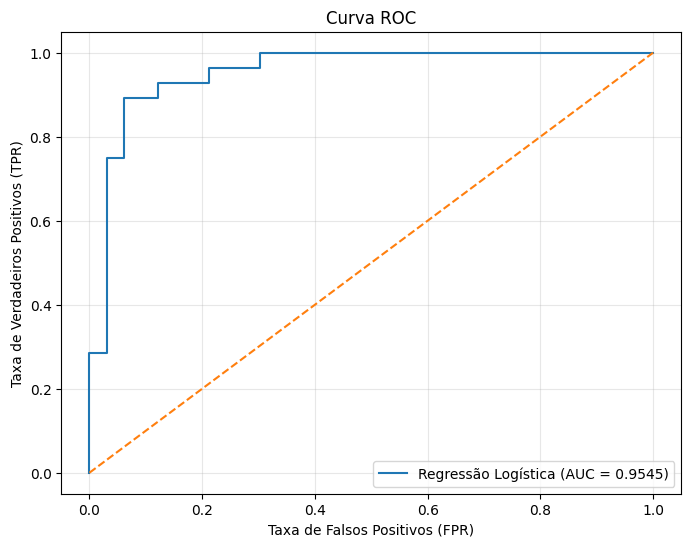

In [30]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Regressão Logística (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("Taxa de Falsos Positivos (FPR)")
plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
plt.title("Curva ROC")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


De modo geral, o modelo de regressão logística apresentou um desempenho bastante satisfatório na predição de doença cardíaca. Com acurácia de 86,89%, F1-score de 86,67% e AUC de 0,9545, o modelo conseguiu diferenciar bem os pacientes com e sem a doença, demonstrando boa capacidade de classificação no conjunto de teste. O recall elevado mostra que a maior parte dos pacientes com doença foi identificada corretamente, o que é especialmente importante em um contexto de saúde, no qual não detectar um caso real pode trazer consequências graves.

A matriz de confusão reforça essa análise. Nela, observa-se que o modelo classificou corretamente 27 pacientes sem doença e 26 pacientes com doença, errando apenas 8 casos no total. Entre esses erros, houve 6 falsos positivos e apenas 2 falsos negativos. Esse resultado é positivo, porque mostra que o modelo teve mais tendência a sinalizar alguns pacientes saudáveis como doentes do que deixar de identificar pacientes realmente doentes, o que, em aplicações médicas, costuma ser uma escolha mais segura.

Assim, conclui-se que a regressão logística foi uma abordagem adequada para o problema proposto, pois apresentou bom desempenho, excelente capacidade de separação entre as classes e resultados coerentes com a finalidade do projeto. Além disso, por ser um modelo simples e de fácil interpretação, ele se mostra uma boa solução inicial para apoiar análises preditivas de risco cardíaco.